# Capstone Project: Churn Rate of Credit Card Customers
### Name: Ella Wiggins
#### Dataset Obtained From Kaggle: __[Credit Card Customers](https://www.kaggle.com/datasets/sakshigoyal7/credit-card-customers?sort=votes)__
- The goals of this project are to minimize customer churn and reduce revenue loss by retaining existing customers rather than spending more to acquire new ones, while also empowering employees to make informed decisions that improve services and offerings. To achieve these goals, the project objectives are to identify churn drivers, build a machine learning model based on those factors, use the model to predict customer churn, and develop an application using Fast API and PySide6 for employee interaction. Based on these objectives, the deliverables are an optimized machine learning model, an employee-facing app, and technical documentation detailing the EDA steps, feature engineering, and model evaluation metrics, including accuracy, precision, recall, F1-score, and a confusion matrix.

For this Notebook and the subsequent pipeline based on its findings, the CRISP-DM Framework will be used to find the best results.

1. [__Problem Understanding__](#problem-understanding) <br>
    > a. [Determine Business Objectives](#business-objectives) <br>
    > b. [Assess Situation and Data Needed](#assess-situation-and-data-needed) <br>
    > c. [Produce Project Plan](#project-plan) <br>
2. [__Data Understanding__](#data-understanding) <br>
    > a. [Collect Data](#collect-data) <br>
    > b. [Verify Data Quality](#verify-data-quality) <br>
    > c. [Exploratory Data Analysis](#explore-and-analyze-data) <br>
3. [__Data Preperation__](#data-preperation) <br>
    > a. [Clean Data](#clean-data) <br>
    > b. [Split Data into Training and Testing Sets](#split-data) <br>
    > c. [Data preprocessing and transformation pipeline](#encode-data--feature-engineering) <br>
4. [__Modeling__](#modeling) <br>
    > a. [Model Benchmarking](#test-multiple-models)<br>
    > b. [Select the Model with the Best Performance](#best-model-found-lightgbm) <br>
    > c. [Tune Hyperparameters](#hyperparameter-optimization-using-optuna) <br>
    > d. [Final Pipeline with Hyperparameter Optimization](#final-pipeline-with-hyperparameter-optimization)<br>
5. [__Evaluation__](#evaluation) <br>
    > a. [Check Results](#check-results) <br>
    > b. [SHAP Explainable AI](#shap)<br>
    > c. [Data Model Integrity / Check Data Leakage](#data-leakage-and-model-integrity-test)<br>
    > d. [Check Impact on Business Problem](#financial-impact-analysis) <br>
6. __Deployment__ <br>
    > a. Create Pipeline <br>
    > b. Create Gui <br>
    > c. Integrate Model into App <br>
    > d. Monitor for Data Drift <br>
    > e. Create Documentation for App Implementation <br>

In this notebook, we will go through steps 1-5; step 6 will be implemented outside the notebook. The main objective will be to perform exploratory data analysis of the dataset and build a machine learning model to predict when a customer may leave the company. In the notebook, I will explain each step taken to achieve the goal of this project. 

## Problem Understanding

Business Problem Context:
> A Company that issues credit cards has recently noticed an uptick in customers leaving its service and has only been able to retain them when they call to cancel their credit card accounts. The company wants to switch to a proactive approach to retaining high-risk customers, rather than the reactive approach that has not been working well for them. To make that switch, they would like an app the company can use to identify customers early by showing which transactional or behavioral features are causing them to leave. After identifying those features, can they be used to reliably predict which customers are likely to leave? 

### Business Objectives:
1. Identify factors associated with customer churn. <br>
    > *   * Use SHAP and a correlation graph to highlight features with high churn rates and assess their correlations. <br> 
2. Shift from Reactive to Proactive <br>
    > *   * Train a machine learning model to predict whether a customer will leave, achieving a recall and precision above 80% and an AUC-ROC above 98%. <br>
3. 1. Implement targeted retention strategies based on features associated with high churn to reduce customer attrition.  <br>
    > * If the machine learning model predicts that the customer has a high likelihood of leaving the company, use SHAP values to identify which incentives to offer based on the top features present.  <br>

### Assess Situation and Data Needed:
1. 1. For this situation, a dataset with a decent churn rate is needed to deliver a solution for this business problem.<br>
    > * The dataset was obtained from Kaggle and includes __[Credit Card Customers](https://www.kaggle.com/datasets/sakshigoyal7/credit-card-customers?sort=votes)__, with a 16.1% churn rate, which can be used to develop a solution to this business problem.<br>
2. 1. Measurables of success <br>
    > * For this problem to be considered solved, the model must have recall and precision scores over 80% and an AUC & ROC score over 0.90, to be considered a functional model for this project.<br>
    > * It must also maintain data integrity at over 99% to ensure accurate predictions and prevent data drift, which may make the model unreliable.  <br>

### Project Plan:
> 1. Collect Data<br>
> 2. Conduct Exploratory Data Analysis (EDA) to identify key patterns, trends, and variable relationships using statistical summaries and visualizations.<br>
> 3. Split the dataset into training and testing sets.<br>
> 4. Data preprocessing and transformation pipeline.<br>
> 5. Model benchmarking.<br>
> 6. Select the model with the highest performance.<br>
> 7. Tune hyperparameters using Optuna, running 30 trials to determine the best hyperparameters.<br>
> 8. Evaluate the model using the test dataset.<br>
> 9. Use Shapley values, a method from cooperative game theory, to identify which input features have the greatest impact on the model’s predictions.<br>
> 10. Show final deliverables to potential customers, including cost savings achieved with the solution.<br>
> 11. Refactor code for production using modularization.<br>
> 12. Implement robust logging and exception handling to facilitate system maintenance and debugging.<br>
> 13. Develop an app with a backend and a frontend.<br>
> 14. Simulate for latency, thresholds, and drift checks.<br>




### Import the necessary Libaries

In [1]:
# Access project root so notebook can import from src/
import sys
import os
import json
sys.path.append(os.path.abspath(os.path.join('..')))

# Data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn modules for preprocessing, modeling, and evaluation
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, TargetEncoder
from sklearn.pipeline import Pipeline

# Overbalance Handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# Feature evaluation
import shap

# Import functions from EDA.py
from src.utils.EDA import categorize_and_print_columns, plot_feature_grid, find_outliers

# Import transformer classes from Modeling.py
from src.utils.Modeling import (
    FeatureEngineering,
    evaluate_models,
    feature_selector,
    hyperparameter_tuning,
    evaluate_classifier,
 )

# Warnings and logging
import logging
import warnings

warnings.filterwarnings('ignore')
logging.getLogger('lightgbm').setLevel(logging.ERROR)
logging.getLogger('sklearn').setLevel(logging.ERROR)

#### Pip install Kaggle and IPYWidgets to use the Kaggle API to download the most recent version of the data, if needed.

In [2]:
#%pip install kagglehub
#%pip install ipywidgets
#%pip install kagglehub[pandas-datasets]

#### Import Kaggle Libraries and IPYWidgets

In [3]:
# import data
import kagglehub
from kagglehub import KaggleDatasetAdapter
import ipywidgets as widgets

#kagglehub.login()

## Data Understanding
- The dataset was obtained from "__[Credit Card Customers](https://www.kaggle.com/datasets/sakshigoyal7/credit-card-customers?sort=votes)__" on Kaggle by Sakshi Goyal.
- The originating site for the Dataset: __[Analyttica](https://leaps.analyttica.com/home)__
- The dataset has around 10,127 rows with 23 columns. I will drop three columns before I start analyzing the data, since two of the three seem to be leftovers from a previous model using a Naive Bayes classifier, and the other column is the client number, which is not needed for this preanalysis and will only be needed for the app.

### Collect Data

In [4]:
# Create directory for data if it doesn't exist
os.makedirs('../data/', exist_ok=True)

# Define the file path for the dataset
file_path = "BankChurners.csv"

# Load the dataset using kagglehub
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "sakshigoyal7/credit-card-customers",
  file_path)

# Save original dataframe to data directory
df.to_csv('../data/BankChurners.csv', index=False)

Read the file from Kaggle using Kaggle's API, and save it to the folder labeled “data” to store the original data for later use.

In [5]:
#drop last two columns AND CLIENTNUM which are not needed for analysis
df.drop(['Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
         'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2', 
         'CLIENTNUM'], 
         axis=1, inplace=True)

The three columns mentioned earlier need to be dropped before performing any analysis. The first two columns lacked context but were assumed to be from another analysis using a Naive Bayes classifier, and the last column was the client number, which wasn't needed to understand anything about the customers. 

### Verify Data Quality

In [6]:
display(df.head())
df.info()
print('Duplicates:', df.duplicated().sum())

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Attrition_Flag            10127 non-null  object 
 1   Customer_Age              10127 non-null  int64  
 2   Gender                    10127 non-null  object 
 3   Dependent_count           10127 non-null  int64  
 4   Education_Level           10127 non-null  object 
 5   Marital_Status            10127 non-null  object 
 6   Income_Category           10127 non-null  object 
 7   Card_Category             10127 non-null  object 
 8   Months_on_book            10127 non-null  int64  
 9   Total_Relationship_Count  10127 non-null  int64  
 10  Months_Inactive_12_mon    10127 non-null  int64  
 11  Contacts_Count_12_mon     10127 non-null  int64  
 12  Credit_Limit              10127 non-null  float64
 13  Total_Revolving_Bal       10127 non-null  int64  
 14  Avg_Op

### Data Dictionary

- Dataset's general information, including data type, target variable, and row and column counts. And there are no duplicate or missing values.<br>
Row Count: 10,127  |  Column Count: 20<br>
Missing: 0         |  Duplicated: 0
1. Attrition_Flag(_string_):
    > __Target Variable__: Internal event (customer activity) variable - Existing Customer / Attrited Customer.
2. Customer_Age(_int_): 
    > Demographic variable - Customer's Age in Years.
3. Gender(_string_): 
    > Demographic variable - M=Male, F=Female.
4. Dependent_count(_int_): 
    > Demographic variable - Number of dependents.
5. Education_Level(_string_): 
    > Demographic variable - Educational Qualification (e.g., Graduate, High School).
6. Marital_Status(_string_): 
    > Demographic variable - Married, Single, Divorced, Unknown.
7. Income_Category(_string_): 
    > Demographic variable - Annual Income Category (e.g., < $40K, $40K - 60K).
8. Card_Category(_string_): 
    > Product Variable - Type of Card (Blue, Silver, Gold, Platinum). 
9. Months_on_book(_int_): 
    > Period of relationship with bank (Months).
10. Total_Relationship_Count(_int_): 
    > Total no. of products held by the customer.
11. Months_Inactive_12_mon(_int_): 
    > No. of months inactive in the last 12 months. 
12. Contacts_Count_12_mon(_int_): 
    > No. of Contacts in the last 12 months. 
13. Credit_Limit(_float_): 
    > Credit Limit on the Credit Card. 
14. Total_Revolving_Bal(_int_): 
    > Total Revolving Balance on the Credit Card. 
15. Avg_Open_To_Buy(_float_): 
    > Open to Buy Credit Line (Average of last 12 months). 
16. Total_Amt_Chng_Q4_Q1(_float_): 
    > Change in Transaction Amount (Q4 over Q1). 
17. Total_Trans_Amt(_int_): 
    > Total Transaction Amount (Last 12 months). 
18. Total_Trans_Ct(_int_): 
    > Total Transaction Count (Last 12 months). 
29. Total_Ct_Chng_Q4_Q1(_float_): 
    > Change in Transaction Count (Q4 over Q1). 
20. Avg_Utilization_Ratio(_float_): 
    > Average Card Utilization Ratio. 

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Customer_Age,10127.0,46.325960,8.016814,26.0,41.000,46.000,52.000,73.000
Dependent_count,10127.0,2.346203,1.298908,0.0,1.000,2.000,3.000,5.000
Months_on_book,10127.0,35.928409,7.986416,13.0,31.000,36.000,40.000,56.000
Total_Relationship_Count,10127.0,3.812580,1.554408,1.0,3.000,4.000,5.000,6.000
Months_Inactive_12_mon,10127.0,2.341167,1.010622,0.0,2.000,2.000,3.000,6.000
Contacts_Count_12_mon,10127.0,2.455317,1.106225,0.0,2.000,2.000,3.000,6.000
Credit_Limit,10127.0,8631.953698,9088.776650,1438.3,2555.000,4549.000,11067.500,34516.000
Total_Revolving_Bal,10127.0,1162.814061,814.987335,0.0,359.000,1276.000,1784.000,2517.000
Avg_Open_To_Buy,10127.0,7469.139637,9090.685324,3.0,1324.500,3474.000,9859.000,34516.000
Total_Amt_Chng_Q4_Q1,10127.0,0.759941,0.219207,0.0,0.631,0.736,0.859,3.397


After using describe on the data set, there are a couple of things that can be inferred from this set:

1. High Financial Variance<br>

    >a. __Credit_Limit__ and __Avg_Open_To_Buy__ both exhibit right-skewed distributions with outliers; thus, the mean data are spread and may contain many outliers. This means the model may be skewed if outliers are not handled.<br>

2. Low Card Utilization<br>

    >a.__Avg_Utilization_Ratio__ signals minimal card usage: 50% of customers use only 17.6% of their limit, while 25% use just 2.3%. Low utilization rates in inactive cards may be strongly correlated with churn.<br>

3. Engagement Metrics<br>

    >a. __Total_Trans_Ct__ shows that, on average, there are only about 64 uses per year, and with the average use rate of __Total_Ct_Chng_Q4_Q1__ below 1.0 at 0.712, it suggests that customers are slowing down in using the company's products. This may indicate possible churn. <br>

4. Satisfaction Decline<br>

    >a. __Months_Inactive_12_mon__ shows that at least 75% of customers have remained inactive for about 2 months per year, with a maximum of about 6 months. This may indicate they are considering churning, depending on their satisfaction with the company's products. <br>

    >b. A decline in customer satisfaction may be reflected in __Contacts_Count_12_mon__; at least 75% of customers contact the company in 2 months each year, with a maximum of 6 months. While not all contacts indicate dissatisfaction, satisfaction may decrease as the number of inactive months increases.<br>

### Explore and Analyze Data

In [8]:
column_types = categorize_and_print_columns(df)


--- Feature Categorization ---

Binary Columns (2):
--------------------------------------------------
 Attrition_Flag          | Gender
--------------------------------------------------

Categorical Columns (4):
--------------------------------------------------
 Education_Level         | Income_Category
 Marital_Status          | Card_Category
--------------------------------------------------

Numeric_categorical Columns (4):
--------------------------------------------------
 Dependent_count         | Months_Inactive_12_mon
 Total_Relationship_Count | Contacts_Count_12_mon
--------------------------------------------------

Numerical Columns (10):
--------------------------------------------------
 Customer_Age            | Total_Amt_Chng_Q4_Q1
 Months_on_book          | Total_Trans_Amt
 Credit_Limit            | Total_Trans_Ct
 Total_Revolving_Bal     | Total_Ct_Chng_Q4_Q1
 Avg_Open_To_Buy         | Avg_Utilization_Ratio
--------------------------------------------------


For easier viewing with graphs, the columns were split into the following groupings: binary columns (columns with only two options), categorical columns (columns with more than two unique options), numeric categorical columns (categorical columns that are numeric in nature and have a limited number of options), and numerical columns (columns that contain only numbers and vary in range).

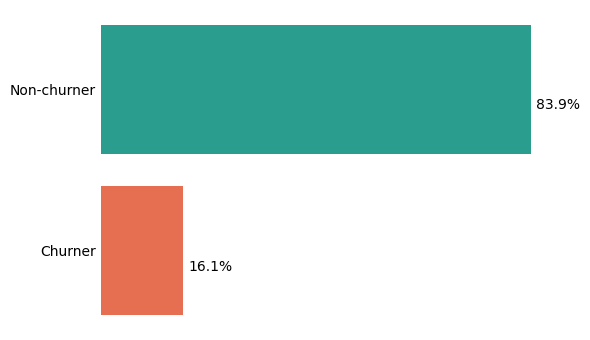

In [9]:
counts = df['Attrition_Flag'].value_counts(normalize=True).mul(100).sort_values()
labels = counts.index.map({'Existing Customer': 'Non-churner', 'Attrited Customer': 'Churner'})

fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.barh(labels, counts, color=['#e76f51','#2a9d8f' ])

ax.spines[['top', 'right', 'bottom', 'left']].set_visible(False)
ax.xaxis.set_visible(False)
ax.tick_params(axis='y', length=0) 

for bar in bars:
    ax.text(bar.get_width() + 1, bar.get_y() + 0.3, f"{bar.get_width():.1f}%", va='center')

plt.tight_layout()


The churn rate in the dataset was 16.1%, while the non-churn rate was 83.9%, resulting in a significant imbalance. This will make it harder to find a machine learning model that would be able to handle the imbalance, since unoptimized models tend to skew more to the majority class, which is the customer who did not churn. 


In [10]:
df.rename(columns={'Attrition_Flag': 'churn'}, inplace = True)
df['churn'] = df['churn'].map({'Attrited Customer': 1, 'Existing Customer': 0})


I will rename the Attrition_Flag column for easier interpretation and set Attrited Customer to 1 and Existing Customer to 0 to make it easier to view the churn percentage for each feature.

In [11]:
df.head()

,churn,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,0,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,0,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,0,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,0,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,0,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


The column changes was completed successfully.

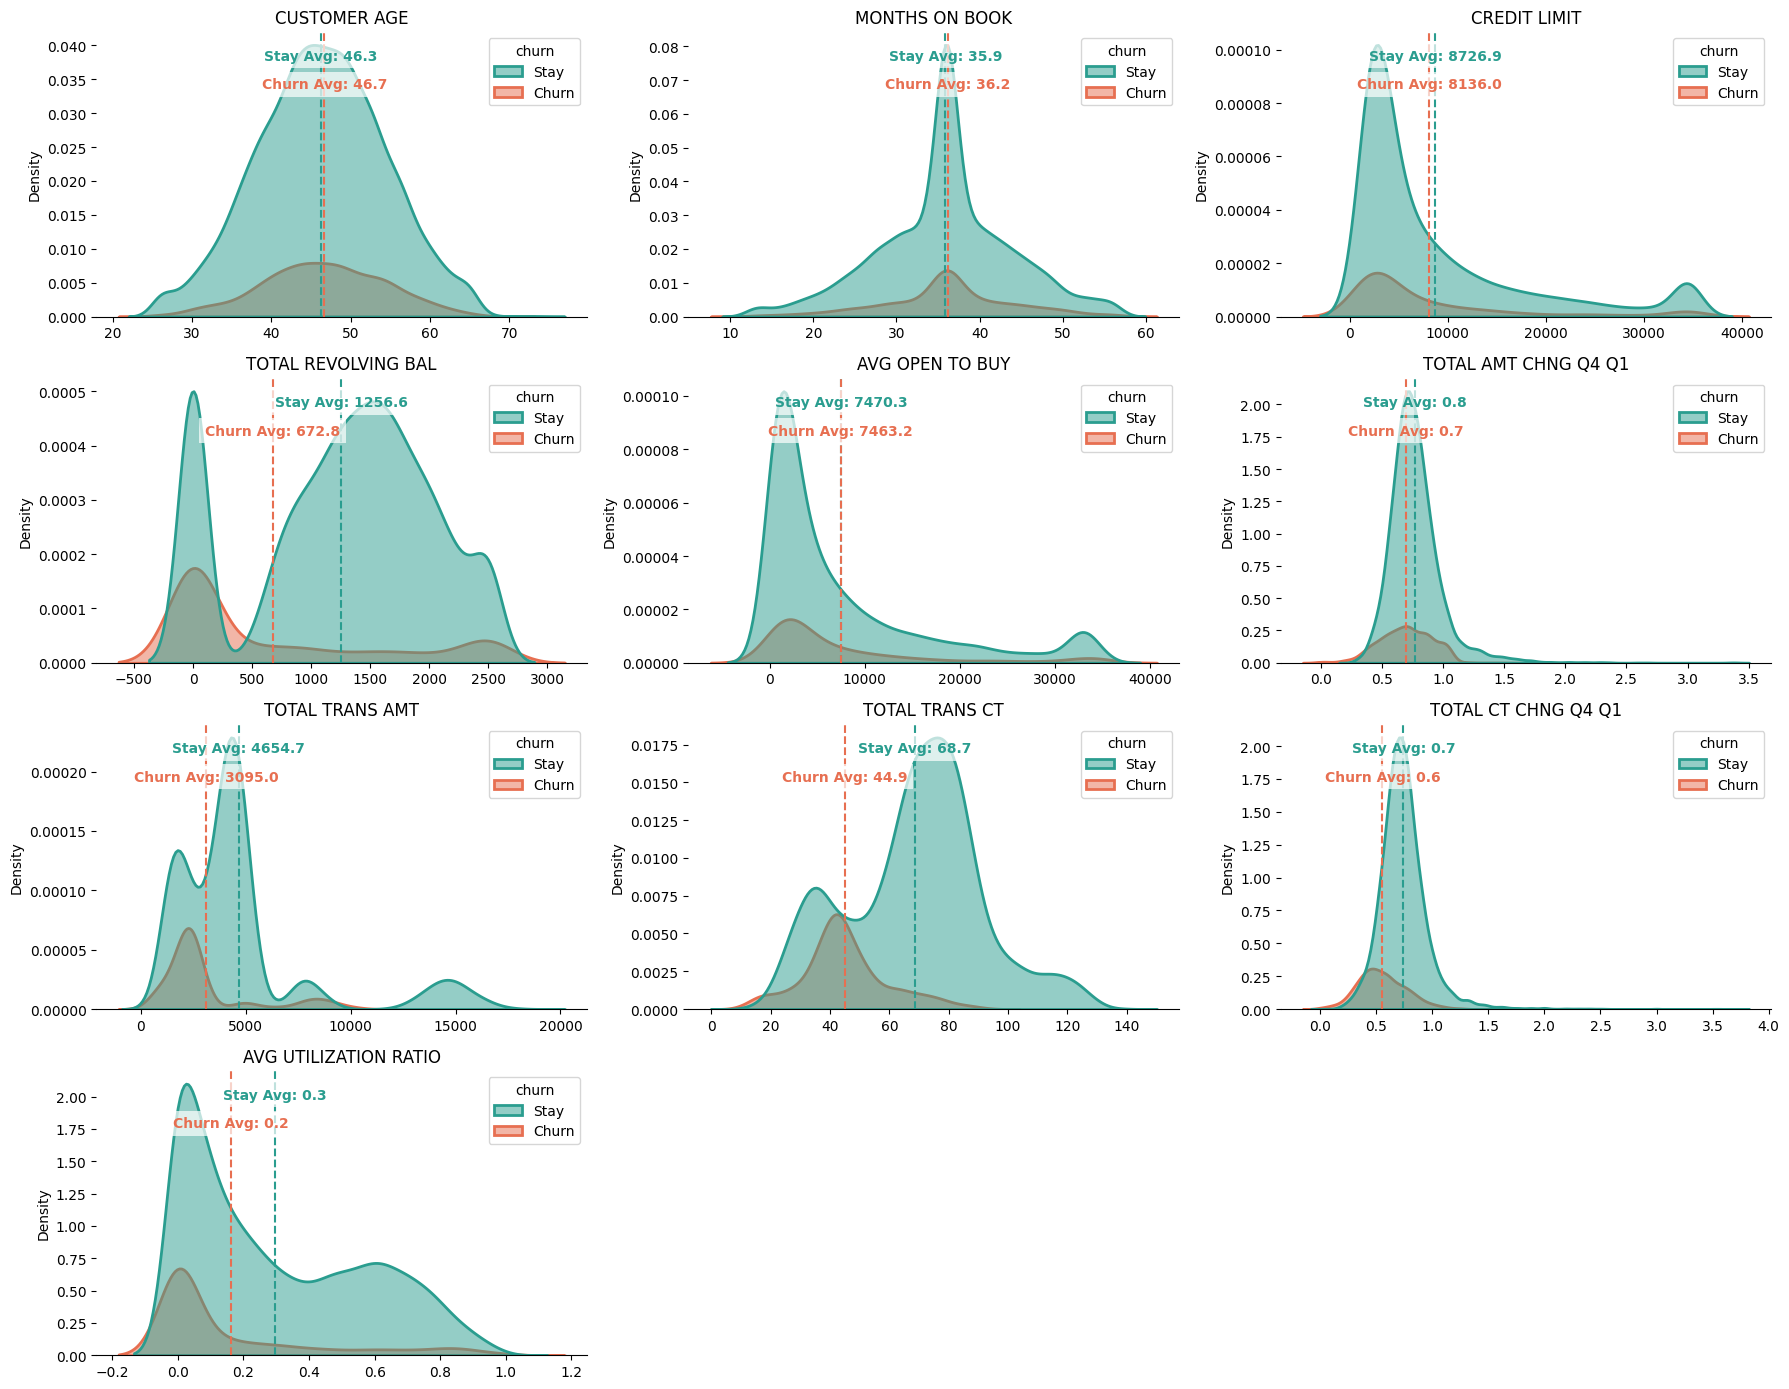

In [12]:
plot_feature_grid(
    df,
    features=column_types['numerical'],
    barplot=False,
    target='churn'
)

Insights derived from Kernel Density Estimate (KDE) plots of Demographic and Behavioral Numerical Features:

  > 1. __Transactional Velocity (total_trans_ct & total_trans_amt)__: A gap exists between retained and churned customers. On average, retained customers make __70 transactions__ per year and spend around __$4,654__. Churned customers make __45 transactions__ and spend about __$3,095__ per year. This may suggest customers slow down their card usage before they churn. 

  > 2. __Zero-Balance Signal (total_revolving_bal)__: There is a clear jump in the revolving balance graph over $0. This could indicate greater financial responsibility, but in credit portfolios, it may suggest that the customer has switched to another company's products.

  > 3. __Quarterly Momentum (total_ct_chng_q4_q1 & total_amt_chng_q4_q1)__: Churners show a compression in spending amount and count from quarter 1 to quarter 4. This shows a gradual decrease in card usage, not a sudden stop.

  > 4. __High-Value Exposure (credit_limit)__: There is a prominent peak over __$34,000+ in credit limit__ with customers who have churned. The company is losing its highest-cap accounts, which magnifies potential revenue loss. 

  > 5. __Demographic vs Behavioral (customer_age & months_on_book)__: Curves of retention and churn are nearly identical for customer age and months on book. The issue is more about __behavior__ (card usage) than __demographics__ (who the customers are). 

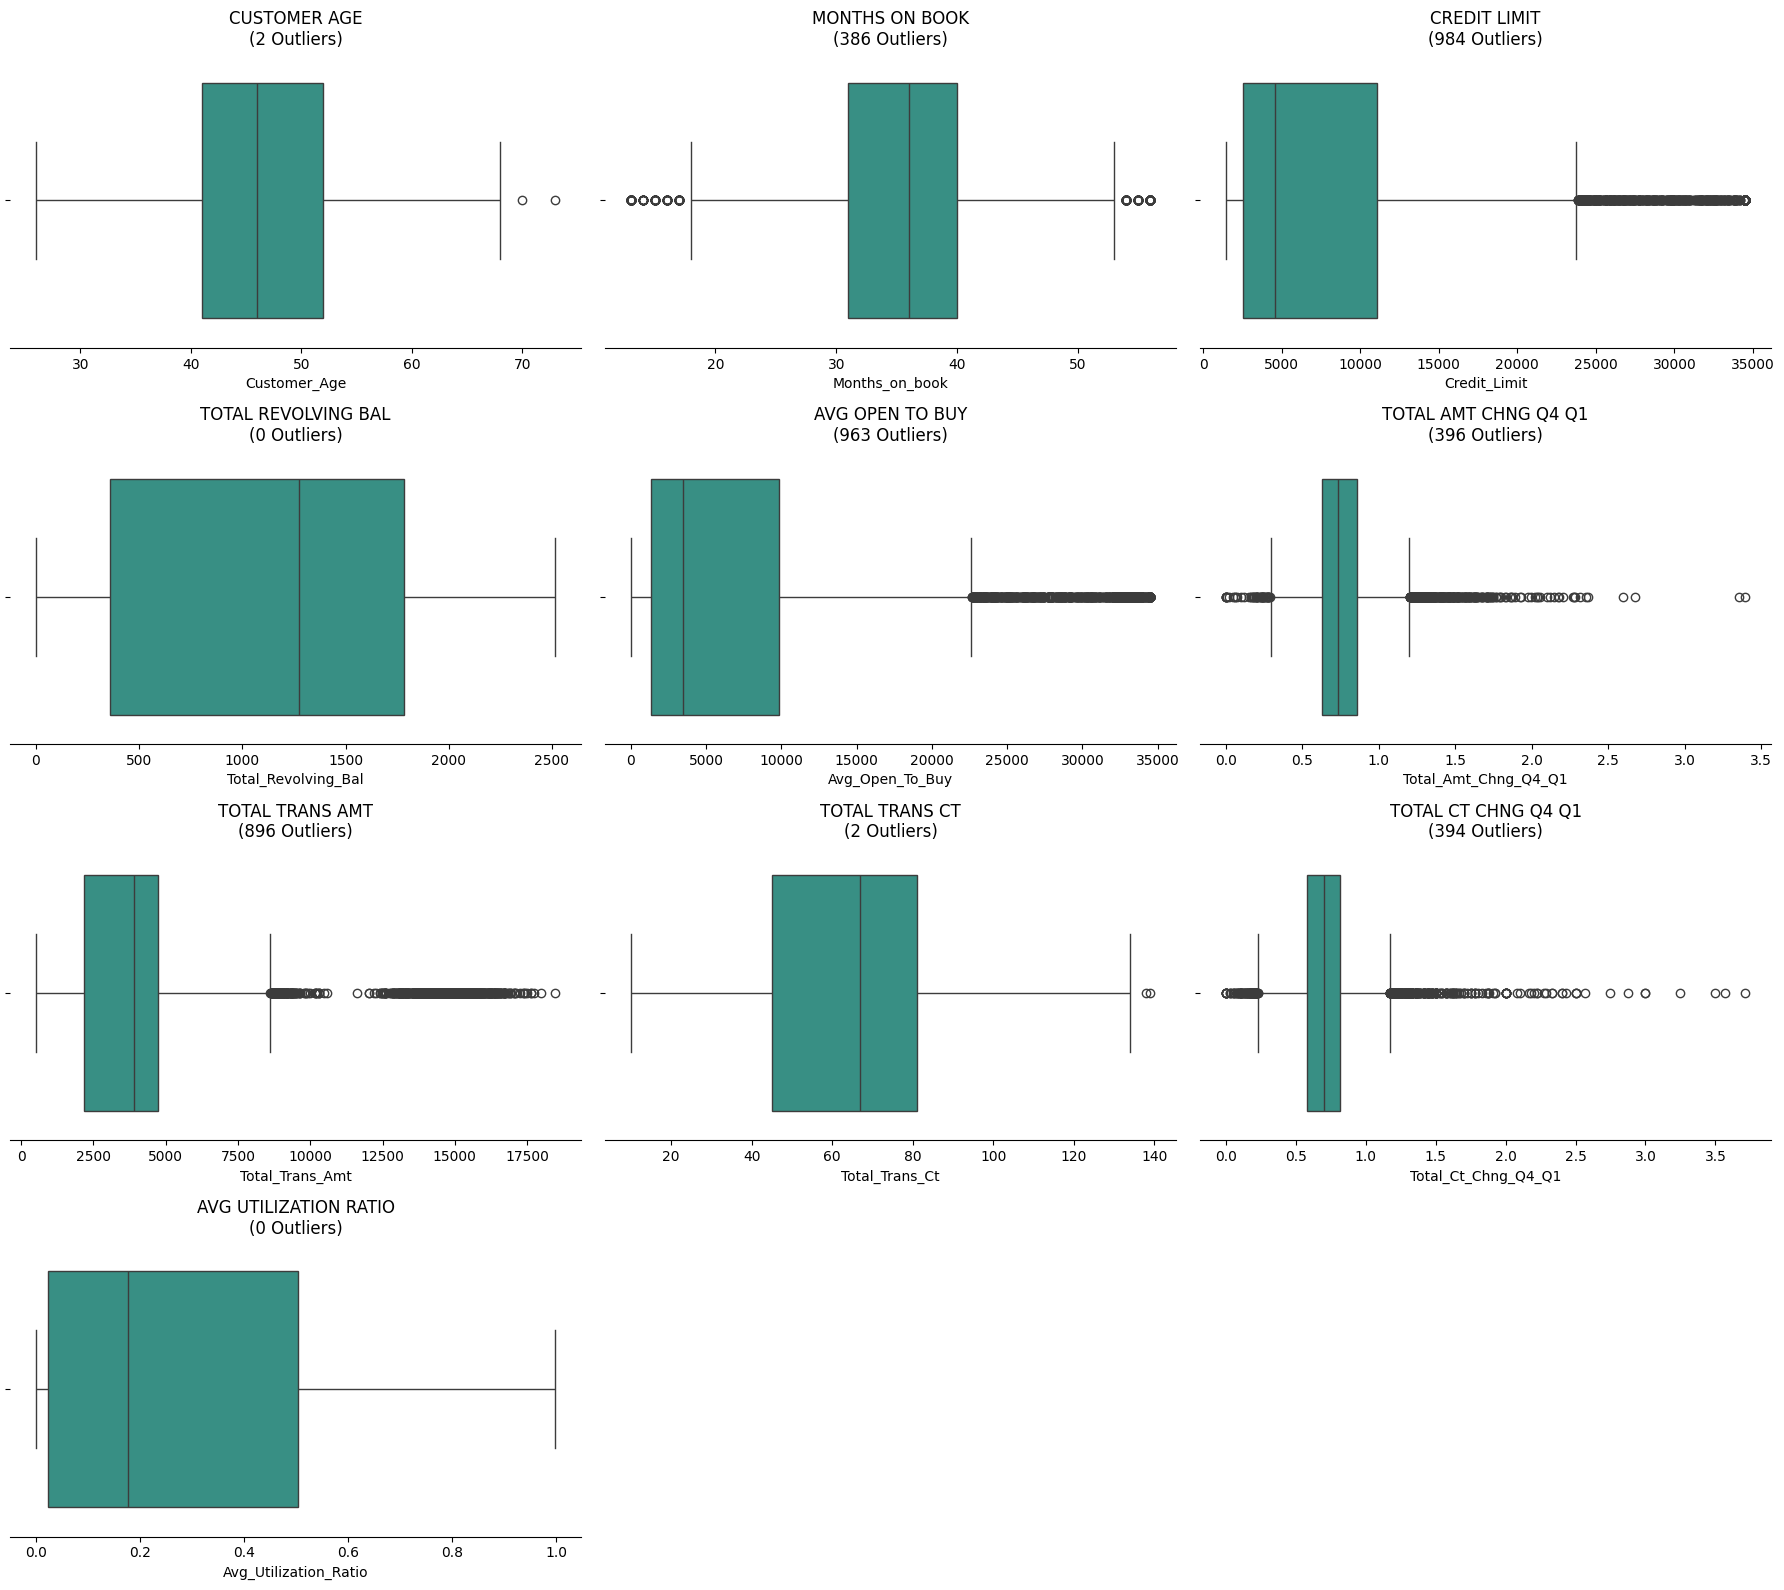

In [13]:
find_outliers(df, features=column_types['numerical'])

> * Looking at the data extremes, there are a few fascinating patterns that point directly to bank policy and sudden shifts in customer behavior:

  > * __The Secret Ceiling (credit_limit & avg_open_to_buy)__: These features show a massive cluster of outliers (984 and 963, respectively) that abruptly flatten out right around $34,500. This isn't random; it strongly implies a hard institutional cap set by the bank's internal credit policy.

  > * __The High-Roller Gap (total_trans_amt)__: Out of the 896 outliers, the majority of the baseline customers spend under $5,000 annually. However, a distinct, high-value group stretches all the way up to $17,500. Losing individuals in this outlier bracket represents an outsized revenue hit.

  > * __Sudden Whiplash (total_amt_chng_q4_q1 & total_ct_chng_q4_q1)__: With roughly 395 outliers on both ends of these distributions, we see two extremes. On the right, you have customers who suddenly doubled their card usage heading into the final quarter. On the left, you see people whose activity completely fell off a cliff. In a churn model, the left tail is our problem area.

In [14]:
numerical_categorical = column_types['categorical'] + column_types['numeric_categorical'] + ['Gender']

Combined the Categorical, Numerical, and the Gender column to complete a total categorical column for the next graph. 

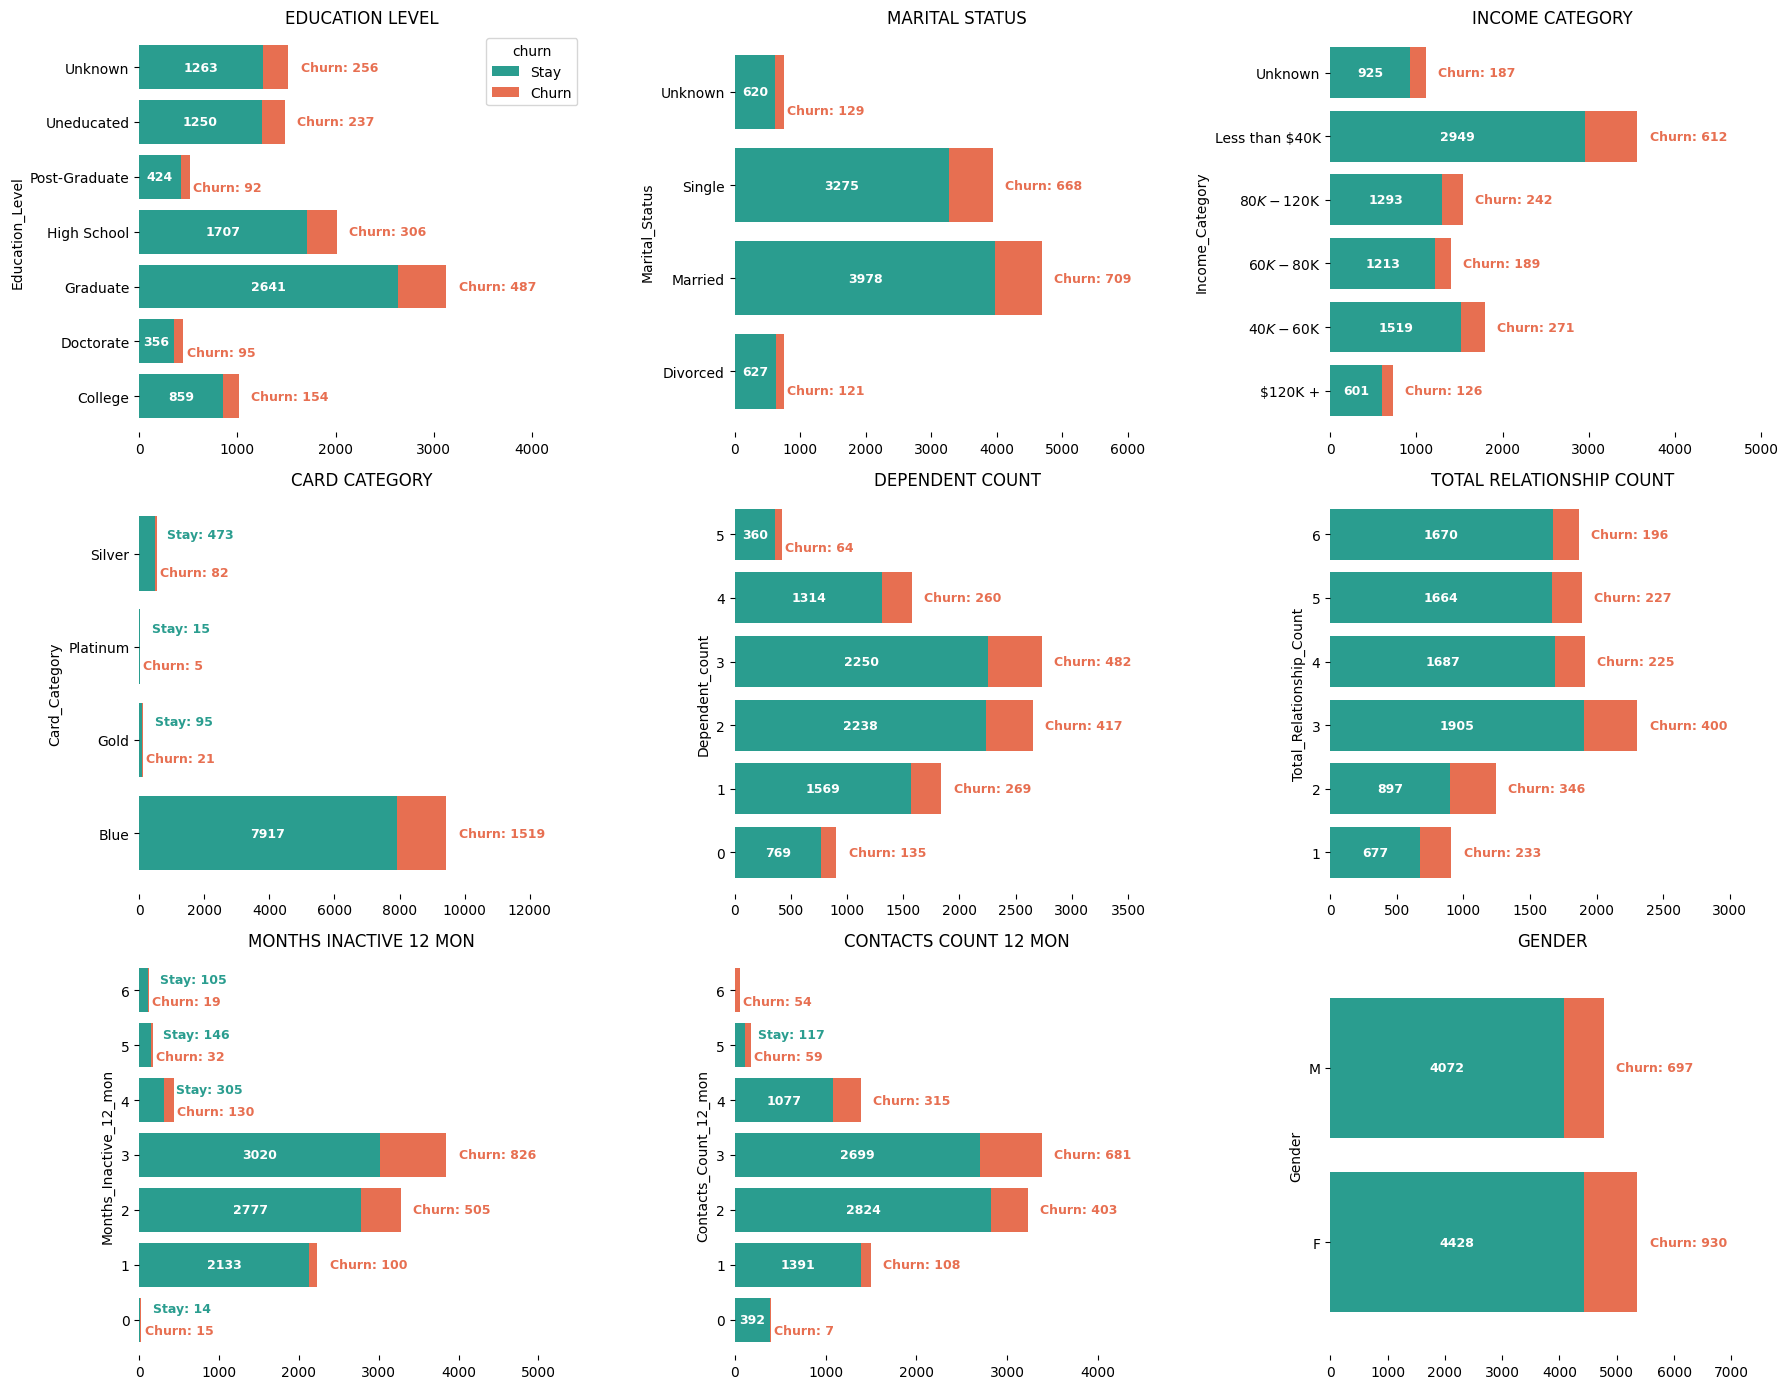

In [15]:
plot_feature_grid(df, 
                  features=numerical_categorical, 
                  barplot=True, 
                  target='churn')

* Analyzing how customer profile categories overlap with churn reveals some intense behavioral thresholds:
  > 1. __The "Single-Product" Trap (total_relationship_count)__: Most bank users hold several products, but a small group with only 1 or 2 products has a massive churn rate—showing that low product stickiness makes it easy for customers to walk away.

  > 2. __The 5-Contact Breaking Point (contacts_count_12_mon)__: This is a red flag area in the features. Once a customer calls support 5 times in a year, their probability of leaving spikes to nearly 50%. By contact 6, it approaches 100%. This isn't just an outlier statistic; it’s an active distress signal showing imminent churn.

  > 3. __The 3-Month Silent Window (months_inactive_12_mon)__: Over 950 departed users sit cleanly within the 3-to-4-month inactivity bracket. In terms of absolute volume, this is the main danger zone where a customer transitions from "just not using the card" to completely checking out.

  > 4. __The Blue Card Exposure (card_category)__: While premium tiers exist, the entry level Blue Card tier accounts for over 93% of the customer base and has the highest baseline churn. Due to its size, even a slight rise in Blue Card departures triggers a major financial ripple across the portfolio.



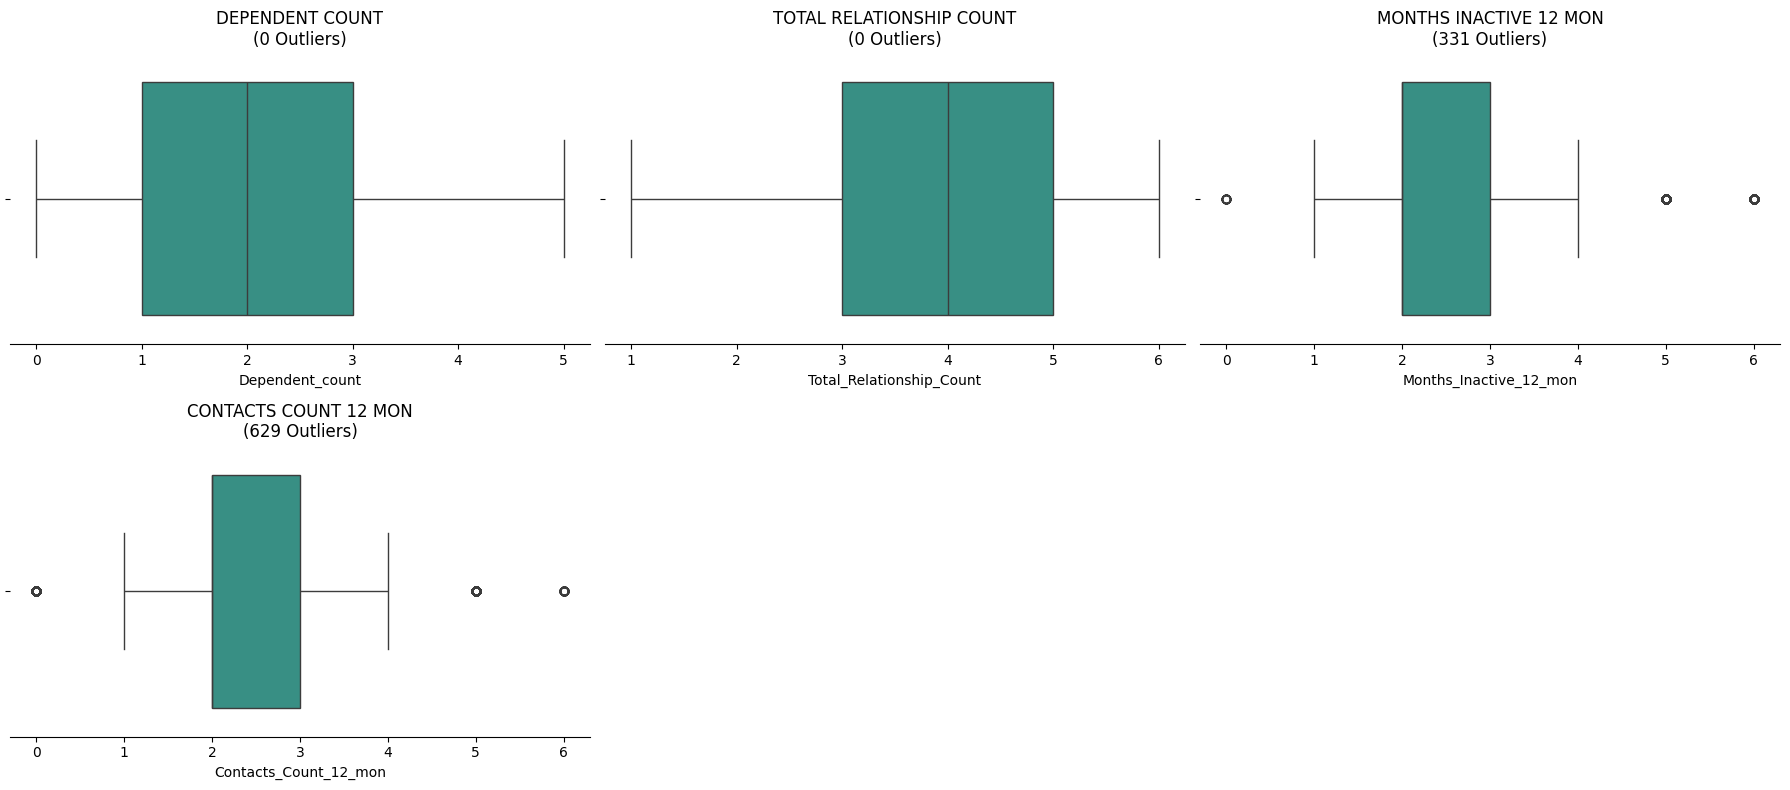

In [16]:
find_outliers(df, features=column_types['numeric_categorical'])


While these specific categories don't have many statistical anomalies, the ones that do appear are incredibly vital. For instance, hitting 5+ customer support contacts or crossing into 5–6 months of complete dormancy are technically outliers on a boxplot, but they aren't noise. They represent "ghost accounts" or highly frustrated users on the verge of abandoning the bank entirely. Treating these specific extremes as critical early-warning tripwires is exactly how the bank can intercept churn before it happens.

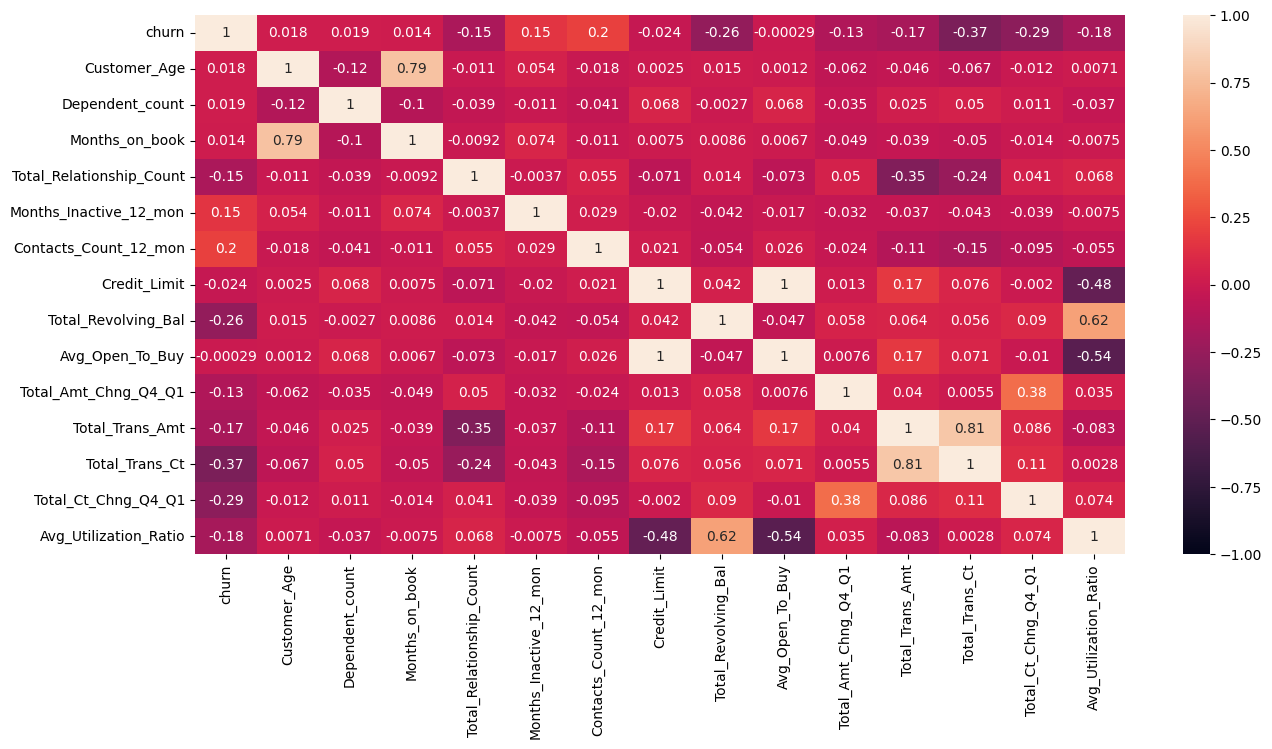

In [17]:
# Correlation matrix and heatmap
corr_matrix = df.corr(numeric_only=True)
churn_corr = corr_matrix['churn'].sort_values(ascending=False)

plt.figure(figsize=(15, 7))
sns.heatmap(corr_matrix, vmin=-1, vmax=1, annot=True)
plt.show()

* Using a correlation heatmap to map our numerical features against churn shows us exactly where the problems lie. The data tells a very clear story: a customer's risk profile isn't defined by who they are, but by how their habits change.

    >  __The Top Churn Accelerators: * Frustration & Outreach (contacts_count_12_mon):__ As customer service interactions climb, churn risk follows lockstep. It is the strongest positive linear indicator of a customer on the way out.

    >  __The Activity Fade (total_trans_ct & total_ct_chng_q4_q1)__: A dropping transaction count and a collapsing quarterly momentum score share a strong inverse relationship with churn. When card swipes slow down, the countdown to departure has officially started.

    > __The Ghost Balance (total_revolving_bal)__: Portfolios hitting a $0 balance carry a heavily elevated risk of churning, marking them as completely idle accounts.

* __Spotting Redundancies (Pipeline Cleanup)__: The heatmap also did us a massive favor by exposing features that are essentially saying the exact same thing, allowing us to streamline our data inputs:
  > __Timeline Mirroring (customer_age vs. months_on_book)__: Unsurprisingly, older customers have naturally held accounts longer, making one of these redundant.

  > __Usage Driving Volume (total_trans_amt vs. total_trans_ct)__: People who swipe their cards more frequently naturally stack up higher annual spend.

  > __The Perfect Twins (credit_limit vs. avg_open_to_buy)__: These two variables share a near-perfect linear correlation, so we can safely drop one without losing any predictive power.

  > __The Profitability Anchor: * Interest-Bearing Stability (total_revolving_bal vs. avg_utilization_ratio)__: These metrics share a powerful negative correlation with churn. From a business perspective, this shows that your revolving tier—the active users who carry a balance and generate interest revenue—represents the bank's most stable and loyal customer segment.

* When you look at the matrix as a whole, the demographic traits completely fade into the background. Churn is almost entirely a behavioral breakdown. By focusing our pipeline on behavioral velocity rather than static profile metrics, we give our machine learning models the exact type of high-leverage data they need to intercept an account before it goes dark.

## Data Preperation:

### Clean Data

In [18]:
df.columns= [x.lower() for x in df.columns]
df = df.drop(columns=['customer_age', 'gender', 'avg_open_to_buy'])

Will convert all columns to lowercase for easier data manipulation and drop the redundant column (__customer_age__, __avg_open_to_buy__) mentioned above. We will also drop __gender__ from the dataset to remain in compliance with the Equal Credit Opportunity Act (ECOA) regulations..

### Split Data

In [19]:
X = df.drop(columns=['churn'])
y = df['churn'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

Now we will split the data into training and testing sets.

In [20]:
train_prop = y_train.value_counts(normalize=True)
test_prop = y_test.value_counts(normalize=True)
print(f"{'Metric':<25} | {'Training Set':<18} | {'Test Set':<18}")
print('-' *60)
print(f"{'Total Samples':<25} | {len(y_train):<18} | {len(y_test):<18}")
print(f"{'Number of Features':<25} | {X_train.shape[1]:<18} | {X_test.shape[1]:<18}")
print(f"{'Non-Churn %':<25} | {train_prop[0]:<18.2%} | {test_prop[0]:<18.2%}")
print(f"{'Churn %':<25} | {train_prop[1]:<18.2%} | {test_prop[1]:<18.2%}")
print('-' *60)

Metric                    | Training Set       | Test Set          
------------------------------------------------------------
Total Samples             | 8101               | 2026              
Number of Features        | 16                 | 16                
Non-Churn %               | 83.93%             | 83.96%            
Churn %                   | 16.07%             | 16.04%            
------------------------------------------------------------


Next, the data was partitioned using Scikit-Learn’s train_test_split with a test_size=0.2. We used stratify=y and set random_state=42 to ensure the 16% minority churn rate was perfectly balanced and reproducible across both the training and test sets.

In [21]:
X_train.head()

,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio
2856,0,Unknown,Married,Less than $40K,Blue,24,4,3,2,2570.0,2230,0.686,1755,42,0.448,0.868
6515,3,High School,Single,$60K - $80K,Silver,36,5,2,3,25276.0,0,0.849,2282,38,0.583,0.000
7141,2,High School,Married,$80K - $120K,Blue,30,6,3,1,11670.0,915,0.892,4277,89,0.854,0.078
632,2,Graduate,Married,Less than $40K,Blue,24,3,1,3,3124.0,1593,0.869,1652,41,0.367,0.510
3496,1,Graduate,Single,$120K +,Blue,40,4,2,3,34516.0,1185,0.725,3874,72,0.714,0.034


After reviewing all the steps and the table, it is clear that the index is missing numbers, confirming that the data was split successfully. __gender__, __customer_age__, and __avg_open_to_buy__ were all dropped as intended. The X_train table no longer contains the churn column, so it is ready for the upcoming small pipeline.

In [22]:
# Categorize columns in training set for use in pipeline
types = categorize_and_print_columns(X_train)


--- Feature Categorization ---

Categorical Columns (4):
--------------------------------------------------
 education_level         | income_category
 marital_status          | card_category
--------------------------------------------------

Numeric_categorical Columns (4):
--------------------------------------------------
 dependent_count         | months_inactive_12_mon
 total_relationship_count | contacts_count_12_mon
--------------------------------------------------

Numerical Columns (8):
--------------------------------------------------
 months_on_book          | total_trans_amt
 credit_limit            | total_trans_ct
 total_revolving_bal     | total_ct_chng_q4_q1
 total_amt_chng_q4_q1    | avg_utilization_ratio
--------------------------------------------------


Categorizing the columns also shows that __customer_age__, __gender__, and __avg_open_to_buy__ are gone, and that all the columns categorized earlier remain the same. Each is again separated into its categories as earlier: numerical, numeric categorical, and categorical. These separate categorizations will be useful when deciding which encoding methods to use for the features in the pipeline.

In [ ]:
for feature in types['categorical'] + types['numeric_categorical']:
    print(feature.upper())
    print('-'*40)
    print(f"{'Value':<20} | {'Count':<8} | {'Proportion':<10}")
    print('-'*40)
    stats = X_train[feature.lower()].value_counts(normalize=True)
    counts = X_train[feature.lower()].value_counts()
    for val, count in stats.items():
        print(f"{val:<20} | {counts[val]:<8} | {count:>8.2%}")
    print('-'*40)

EDUCATION_LEVEL
----------------------------------------
Value                | Count    | Proportion
----------------------------------------
Graduate             | 2482     |   30.64%
High School          | 1650     |   20.37%
Unknown              | 1207     |   14.90%
Uneducated           | 1183     |   14.60%
College              | 796      |    9.83%
Post-Graduate        | 427      |    5.27%
Doctorate            | 356      |    4.39%
----------------------------------------
MARITAL_STATUS
----------------------------------------
Value                | Count    | Proportion
----------------------------------------
Married              | 3755     |   46.35%
Single               | 3142     |   38.79%
Unknown              | 605      |    7.47%
Divorced             | 599      |    7.39%
----------------------------------------
INCOME_CATEGORY
----------------------------------------
Value                | Count    | Proportion
----------------------------------------
Less than $40K   

Checking all categorical columns, including the numeric category columns from the previous code, to determine the proportions of the few options in those columns can help decide which encoding methods to use on the features in the pipeline.

1. __Ordinal Encoding__: These columns have an obvious order to them since they increase each time (e.g., 'Blue' -> 'Silver' in __card_category__).<br>

    >a. __income_category__: Clearly Ranked from'Less than 40k' to'$120K +'<br>

    >b. __education_level__: Clear academic hierarchy 'Uneducated' to 'Doctorate'<br>

    > c. __card_category__: Clear 'Premium' ladder from the lowest 'Blue' to the highest 'Platinum'<br>

2. __One-Hot Encoding__: These columns have no clear stucture to them <br>

    > a. __marital_status__: Only has 4 options, and they do not appear in any order.<br>

Finally, numerical columns separate from these columns, since they do not have any order or a specific end, do not need to be encoded, as they are already numeric.

### Encode Data & Feature Engineering

In [24]:
# Define features for encoding
one_hot_features = ['marital_status']
ordinal_features = {
    'education_level': ['Uneducated',
                        'High School',
                        'College',
                        'Graduate',
                        'Post-Graduate',
                        'Doctorate',
                        'Unknown'],
    'income_category': ['Less than $40K',
                        '$40K - $60K',
                        '$60K - $80K',
                        '$80K - $120K',
                        '$120K +',
                        'Unknown'],
    'card_category': ['Blue',
                      'Silver',
                      'Gold',
                      'Platinum']
}
# Define the column transformer for encoding
transformer = ColumnTransformer(
    transformers=[
        ('ordinal', OrdinalEncoder(categories=list(ordinal_features.values())), list(ordinal_features.keys())),
        ('one_hot', OneHotEncoder(drop=None, sparse_output=False), one_hot_features),
        ],remainder='passthrough')

# Create a pipeline that includes feature engineering and the column transformer
small_processing_pipeline = Pipeline([
    ('engineering', FeatureEngineering()),
    ('transformation', transformer)
]).set_output(transform="pandas")


X_train_small = small_processing_pipeline.fit_transform(X_train, y_train)
display(X_train_small.shape)

(8101, 30)

The initial pipeline applied to the training dataset was a partial version of the final design, primarily used to test different models and identify the best candidate for the data. In this setup, marital_status is assigned One-Hot Encoding, while education_level, income_category, and card_category are assigned Ordinal Encoding.

Instead of manual implementation, Scikit-Learn's ColumnTransformer makes transformations easier.  This component eliminates the need to manually split dataframes or separate columns by processing all specified features in a structured, unified step. For marital_status, no encoded dummy columns were dropped because the category options are unique and meaningful.

The column transformer is executed immediately after the feature engineering section to ensure that custom column creations complete smoothly without interference from the encoding step. In the engineering step, several synthetic features were generated to give the machine learning models deeper signals for predicting churn:

#### Behavioral Ratios:

  > __credit_util_rate__ (__total_revolving_bal / credit_limit__): Measures how much of the available credit the customer uses.
  > __prop_inactive_months__ (__months_inactive_12_mon / months_on_books__): Shows the amount of time the account has been inactive.
  > __avg_trans_amt__ (__total_trans_amt / total_trans_ct__): Calculates average amount spent per transaction.<br>
  > __trans_amt_per_months__ (__total_trans_amt / months_on_book__): Calculates average monthly spending over the account's lifetime.
  > __trans_ct_velocity__ (__total_trans_ct / months_on_book__): This column shows the average number of transactions per month across the account's lifetime, indicating how often the customer uses their card.
  > __util_chng_use__ (__avg_utilization_ratio * total_amt_chng_q4_q1__): This column indicates whether a decrease in spending and a low utilization ratio of the card are associated with potential customer churn.

#### Risk Indicators:

  > __high_inactive__ (__months_inactive_12_mon >= 4__): Flags if the customer was inactive for 4 or more months.
  > __low_contact_freq__ (__contacts_count_12_mon <= 2__): Flags if the customer contacts the company infrequently.
  >  __bal_decrease__ (__total_amt_chng_q4_q1 < 0__): Flags if customer spent less in Q4 than in Q1.
  > __churn_warning_score__ (__high_inactive + low_contact_freq__): This score ranges from 0 to 2 and aggregates the high_inactive and low_contact_freq flags. A score of 2 shows inactivity for 4 or more months and fewer than 3 contacts with the company, a combination associated with increased churn likelihood.

#### Composite Score:

  > __education_income_index__: This column combines a customer's income and education levels. This combination may help identify different churn drivers, such as preferences for rewards, compared to other accounts.

* After the column transformer handles feature engineering and encoding, the pipeline is complete. To ensure compatibility with our models, we set the output to pandas, since the pipeline would otherwise yield a numpy array that models cannot process. Using the pipeline to fit and transform X_train and y_train yields an 8,101-row, 30-column dataset with the new engineered and encoded columns included.

In [25]:
X_train_small.head()

,ordinal__education_level,ordinal__income_category,ordinal__card_category,one_hot__marital_status_Divorced,one_hot__marital_status_Married,one_hot__marital_status_Single,one_hot__marital_status_Unknown,remainder__dependent_count,remainder__months_on_book,remainder__total_relationship_count,...,remainder__prop_inactive_months,remainder__avg_trans_amt,remainder__trans_amt_per_months,remainder__trans_ct_velocity,remainder__util_chng_use,remainder__high_inactive,remainder__low_contact_freq,remainder__bal_decrease,remainder__churn_warning_score,remainder__education_income_index
2856,6.0,0.0,0.0,0.0,1.0,0.0,0.0,0,24,4,...,0.125000,41.785714,73.125000,1.750000,0.595448,0,1,0,1,1
6515,1.0,2.0,1.0,0.0,0.0,1.0,0.0,3,36,5,...,0.055556,60.052632,63.388889,1.055556,0.000000,0,0,0,0,5
7141,1.0,3.0,0.0,0.0,1.0,0.0,0.0,2,30,6,...,0.100000,48.056180,142.566667,2.966667,0.069576,0,1,0,1,6
632,3.0,0.0,0.0,0.0,1.0,0.0,0.0,2,24,3,...,0.041667,40.292683,68.833333,1.708333,0.443190,0,0,0,0,5
3496,3.0,4.0,0.0,0.0,0.0,1.0,0.0,1,40,4,...,0.050000,53.805556,96.850000,1.800000,0.024650,0,0,0,0,9


The small pipeline used on X_train worked well and generated all the needed columns. X_train_small will only be used for testing, not later, since feature selection and models still need to be added; hence 'small'. Due to the earlier imbalance, SMOTE will be applied to see if scores improve. If not, SMOTE won't be used in the final pipeline. SMOTE creates synthetic minority samples for imbalanced data by interpolation, addressing dataset imbalance.

## Modeling

### Test Multiple Models

In [26]:
tree_models={
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1)
}

These tree-based models (e.g., Decision Tree, Random Forest, LightGBM, XGBoost) were chosen because they handle banking data similar to our dataset. They are also among the best-performing model types. Using these models helps us assess data performance and check for overfitting. If XGBoost performs worse than the decision tree classifier, it may indicate very strong features or overfitting. A random forest classifier performs well on small to medium-sized datasets. It is more robust to noise and outliers than a decision tree. XGBoost does very well on imbalanced data and usually achieves high accuracy on similar datasets. Like XGBoost, LightGBM works well with imbalanced data and often matches or exceeds its accuracy, but it trains much faster and uses less RAM. Each machine learning model will be tested. Each is likely to perform better than the previous one.

In [27]:
eval_df = evaluate_models(models=tree_models, X=X_train_small, y=y_train, n_folds=5)

Training and evaluating: Decision Tree...
Training and evaluating: Random Forest...
Training and evaluating: XGBoost...
Training and evaluating: LightGBM...

------- Model Comparison -------
  Model Name   Accuracy  Precision  Recall  F1 Score  AUC-ROC  Time (s)
     LightGBM   0.9700    0.9272    0.8833   0.9045   0.9921    2.1112 
      XGBoost   0.9690    0.9190    0.8856   0.9018   0.9917    2.0630 
Random Forest   0.9588    0.9230    0.8119   0.8635   0.9883    0.9017 
Decision Tree   0.9382    0.8114    0.8042   0.8069   0.8840    0.0687 
--------------
Best Model: LightGBM with an AUC-ROC of 0.9921
--------------


After running the models through the evaluation function, as expected, the Decision Tree classifier had the lowest recall score at 0.8042. The Random Forest classifier achieved a recall of 0.8119. It outperformed the Decision Tree and is more robust to noise and outliers. XGBoost ranked second among all models. It also ran faster than the LightGBM classifier. All model scores are slightly worse than those of the Lmodel, but the results are very close. Given this near tie, I will test both the LightGBM and XGBoost classifiers with SMOTE. This will show if there is any meaningful improvement to help determine the better model. To test SMOTE on these models, a miniature ImbPipeline will be used, similar to the small pipeline created earlier with Sklearn’s pipeline. Set SMOTE’s random state to 42 to keep the run reproducible. The 0.35 sampling strategy was selected to balance the classes without introducing too many synthetic samples, which could risk overfitting and invalidate the results. Both models for the run will be set to LightGBM and XGBoost, respectively. 

In [28]:
# Create a dictionary of pipelines to compare best models with SMOTE included
models_to_test = {
    'LGBM': ImbPipeline([
        ('engineering', FeatureEngineering()),
        ('transformation', transformer),
        ('smote', SMOTE(random_state=42, sampling_strategy=0.35)),
        ('model', LGBMClassifier())
    ]),
    'XGBoost': ImbPipeline([
        ('engineering', FeatureEngineering()),
        ('transformation', transformer),
        ('smote', SMOTE(random_state=42, sampling_strategy=0.35)),
        ('model', XGBClassifier())
    ])
}

In [29]:
results = evaluate_models(models_to_test, X_train, y_train)

Training and evaluating: LGBM...
Training and evaluating: XGBoost...

------- Model Comparison -------
Model Name  Accuracy  Precision  Recall  F1 Score  AUC-ROC  Time (s)
    LGBM     0.9699    0.9156    0.8956   0.9053   0.9921    2.5155 
 XGBoost     0.9686    0.9121    0.8917   0.9014   0.9912    0.3890 
--------------
Best Model: LGBM with an AUC-ROC of 0.9921
--------------


After running the evaluation model function with the new SMOTE pipelines, the results did not improve compared to the previous run. For this dataset, SMOTE will not be used. Both models handle imbalanced datasets well. Based on these and earlier scores, recall and AUC-ROC are slightly better in the LightGBM columns than in the XGBoost columns. Therefore, LightGBM will be used moving forward. Next, the LightGBM model will run through optuna trials to find the best hyperparameters.

### Best Model Found: LightGBM

In [30]:
full_processing_pipeline = Pipeline([
    ('engineering', FeatureEngineering()),
    ('transformation', transformer),
    ('selection', feature_selector(estimator=LGBMClassifier(n_estimators=100, random_state=42, verbosity=-1), 
                                  step=3, 
                                  folds=2, 
                                  min_features_to_select=20)),
    ('model', LGBMClassifier(random_state=42, verbosity=-1))
])

During the Optuna trials, a new full pipeline was developed that mirrors all steps of the final version. This ensures that the final model is built dynamically using the best-tested hyperparameters from the optimization process. The pipeline consists of Feature Engineering, a column transformer handling One-Hot and Ordinal encoding, Feature Selection using RFECV, and the LightGBM classifier. The model's random state was set to 42 for reproducibility, and the verbosity was set to -1 to suppress overhead warnings during the trials.

Optuna evaluates several key hyperparameter groups to optimize the LightGBM model:

  > __Tree Structure (max_depth, num_leaves, min_child_samples)__: These parameters control the tree depth, the total number of decision points, and the minimum number of customers per leaf, helping prevent overfitting.<br>
  > __Learning Velocity (n_estimators, learning_rate)__: These set the total number of trees built and dictate how aggressively each new tree corrects the errors of the previous ones.<br>
  > __Regularization & Anti-Cheating (reg_alpha, reg_lambda, colsample_bytree)__: The first two penalize less important features to keep the model simple and robust. The last parameter, column sampling, forces the model to look at a variety of features rather than relying on a single "crutch" variable, helping it spot subtle signs of churn.<br>
  > __Imbalance Control (scale_pos_weight)__: This parameter gives the model more weight to the minority churn class, addressing the dataset imbalance mentioned earlier. <br>

To streamline feature selection, the pipeline uses the RFECV function to identify the best features. The minimum feature threshold is set to 20 as a starting point, leaving room for Optuna to adjust downward for optimal performance. To accelerate the tuning process, the step count was increased to 3 (meaning RFECV drops the three least important features per cycle instead of just one), and a 2-fold cross-validation split was configured. This split evaluates performance on separate parts of the data, in this case, two pieces, ensuring the model would not focus on noisy features. These pipeline parameters comprise the full pipeline that will be evaluated by the Optuna function. These trials were run using X_train and y_train as dataset inputs, with 50 total runs. The scoring technique for the model was set to F1-Score to balance Precision and Recall while maintaining a high AUC-ROC.

To maximize efficiency, internal cross-validation is set to 5 folds and configured to utilize all available processors to speed up execution. To improve trial performance, Optuna's pruning function was integrated to instantly kill off dead-end trials that fail to improve on previous scores. Once the trials conclude, the final best hyperparameters are saved so they can be exported and used outside the notebook.

### Hyperparameter Optimization using Optuna

In [31]:
results = hyperparameter_tuning(
    X=X_train,
    y=y_train,
    pipeline=full_processing_pipeline,
    n_trials=50, 
    cv=5,        
    scoring='f1',
)

best_min_features = results.pop('min_features_to_select')
clean_results = {k.replace('model__', ''): v for k, v in results.items()}

save_data = {
    'params': clean_results,
    'min_features': best_min_features
}
with open('../data/modeling_results.json', 'w') as f:
    json.dump(save_data, f, indent=4)

[I 2026-05-15 16:30:10,576] A new study created in memory with name: no-name-f29aa2cf-7f6f-415c-b834-7ce65f1fc2f0


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-15 16:30:21,563] Trial 0 finished with value: 0.9069978249303468 and parameters: {'min_features_to_select': 15, 'learning_rate': 0.08030378720883377, 'n_estimators': 900, 'num_leaves': 96, 'max_depth': 12, 'min_child_samples': 66, 'reg_alpha': 0.0068719434070394735, 'reg_lambda': 1.2549551283685114, 'colsample_bytree': 0.6601821972217363, 'scale_pos_weight': 5.689483534432848}. Best is trial 0 with value: 0.9069978249303468.
[I 2026-05-15 16:30:32,389] Trial 1 finished with value: 0.8988816853534262 and parameters: {'min_features_to_select': 12, 'learning_rate': 0.045892514674073646, 'n_estimators': 1000, 'num_leaves': 42, 'max_depth': 3, 'min_child_samples': 100, 'reg_alpha': 0.013273784269417681, 'reg_lambda': 0.014104054135555566, 'colsample_bytree': 0.5404386327773933, 'scale_pos_weight': 2.6159452233202205}. Best is trial 0 with value: 0.9069978249303468.
[I 2026-05-15 16:30:36,557] Trial 2 finished with value: 0.9004911668740634 and parameters: {'min_features_to_select

The outcome of the 50 trials yielded a phenomenal best F1-Score of 0.9078. The optimized hyperparameter values are detailed below:<br>

  > min_features_to_select: 14 <br>
  > learning_rate: 0.02347 <br>
  > n_estimators: 1000 <br>
  > num_leaves: 46 <br>
  > max_depth: 7 <br>
  > min_child_samples: 32 <br>
  > reg_alpha: 0.00106 <br>
  > reg_lambda: 2.44571 <br>
  > colsample_bytree: 0.85249 <br>
  > scale_pos_weight: 3.91385 <br>

Thanks to the integration of the pruning function, the entire 50-trial run was completed in roughly five minutes. For context, a previous baseline run of just 30 trials without pruning took nearly 10 minutes. Implementing automated pruning cut our execution time in half while safely delivering an exceptionally high-performing model architecture.

In [32]:
if os.path.exists('../data/modeling_results.json'):
    with open('../data/modeling_results.json', 'r') as f:
        config = json.load(f)
        
    clean_results = config['params']
    best_min_features = config['min_features']
    print("Successfully loaded saved parameters!")
else:
    print("No saved parameters found. You'll need to run the tuner.")

Successfully loaded saved parameters!


This is to check whether the saved hyperparameter file worked correctly. After running it, the printed statement says the parameters were loaded successfully. 

#### Final Pipeline with Hyperparameter Optimization

In [33]:
final_pipeline = Pipeline([
    ('engineering', FeatureEngineering()),
    ('transformation', transformer),
    ('selection', feature_selector(
        estimator=LGBMClassifier(random_state=42, verbosity=-1), 
        min_features_to_select=best_min_features
    )),
    ('model', LGBMClassifier(
        random_state=42, 
        **clean_results))
])

This is the final pipeline mentioned earlier, with all hyperparameters loaded from the Optuna tuner. This is the pipeline that will be used to test whether the model can identify who is leaving and who will be staying in the company's services. It will first be trained on the X_train and y_train data before being tested on the test data.

## Evaluation

In [34]:
final_pipeline.fit(X_train, y_train)

,steps,"[('engineering', ...), ('transformation', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,columns_to_engineer,None
,transformers,"[('ordinal', ...), ('one_hot', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


It has now been fitted to the train dataset, and it produced the visualization of how the pipeline works:

1. __Feature Engineering__<br><br>

2. __Transformation: Column Transformer__<br><br>

    > a. __Ordinal Encoder__<br>

    > b. __One-Hot Encoder__<br> 

    > c. __Remainder Passthrough__<br>

3. __Selection: Feature Selector__<br><br>

4. __LightGBM Classifier__<br><br>

This visualization shows where all pipeline components fit and what is included in each step, such as the encoding techniques and the model hyperparameters.

In [35]:
y_pred = final_pipeline.predict(X_test)
churn_probs = final_pipeline.predict_proba(X_test)[:, 1]

This code will help define how the model works by predicting whether a customer will churn and the probability of that happening. These two will be used in an evaluation of the classifier to assess how well it performed on the test data provided.

### Check Results

In [36]:
metrics_df = evaluate_classifier(y_test, y_pred, churn_probs)

 ------------- Classifier Evaluation -------------
              precision    recall  f1-score   support

 Non-Churner       0.98      0.98      0.98      1701
     Churner       0.90      0.90      0.90       325

    accuracy                           0.97      2026
   macro avg       0.94      0.94      0.94      2026
weighted avg       0.97      0.97      0.97      2026

Final AUC-ROC: 0.9919

Confusion Matrix Breakdown:
True Neg: 1669 | False Pos: 32
False Neg: 32 | True Pos: 293


#### Final Model Evaluation & Performance

This will be the final pipeline, created with the optimized hyperparameters taken from the Optuna trials. This pipeline will serve as the final model, used to predict on the unseen test set and verify its ability to differentiate between staying and churning accounts.<br>

Testing the final pipeline on the test data showed strong results across core classification metrics:<br>

> __High Recall (0.91 / ~91%)__: The model successfully identifies 91% of actual churners (296 out of the total 325 at-risk individuals). In the company’s environment, maximizing recall is a must because it ensures that the majority of churning customers are flagged for retention campaigns before they officially close their accounts. <br>

> __High Precision (0.91/~91%)__: When the model flags a customer as a churn candidate, it is correct 91% of the time. This will help allocate marketing and retention budgets efficiently, avoiding spending on customers who are unlikely to leave. <br>

> __Balanced F1-Score (0.91)__: This high F1-score indicates that both recall and precision are strong, which could support a retention program that efficiently and consistently identifies at-risk customers. This balance would lead to more sustainable client retention and more stable long-term revenue.<br>

> __Minimized Confusion Matrix Errors__: The confusion matrix reveals a manageable number of errors in both false positives and false negatives. With only 31 False Positives and 29 False Negatives. The cost-benefit trade-off is favorable: the minimal false positive outreach is offset by substantial savings from preventing high-value client losses. Thus, it would improve customer lifetime value and reduce churn-driven revenue loss.<br>

> __Exceptional AUC-ROC (0.9920)__: The model’s strong AUC-ROC score shows a reliable distinction between churners and non-churners. This would allow the business to prioritize and target high-risk accounts with greater confidence. Thus, retention efforts would focus on where they will have the greatest revenue impact.<br>

#### The Integrity Caveat

While the model's results are excellent, data leakage and model integrity tests have been planned to confirm the robustness and reliability of these outcomes. 

In [37]:
transformer_names = final_pipeline.named_steps['transformation'].get_feature_names_out()

selected_mask = final_pipeline.named_steps['selection'].support_

final_feature_names = [name for name, selected in zip(transformer_names, selected_mask) if selected]
features_sorted = sorted(final_feature_names)
mid = (len(final_feature_names) + 1) // 2

print(f"\n -------- Final Feature Selection ({len(final_feature_names)} Features)-------- \n")
for i in range(mid):  # 2 features per row
    col1 = features_sorted[i]
    col2 = features_sorted[i + mid] if (i + mid) < len(final_feature_names) else ""
    print(f"{col1:<35} | {col2}")



 -------- Final Feature Selection (27 Features)-------- 

one_hot__marital_status_Married     | remainder__low_contact_freq
one_hot__marital_status_Single      | remainder__months_inactive_12_mon
one_hot__marital_status_Unknown     | remainder__months_on_book
ordinal__card_category              | remainder__prop_inactive_months
ordinal__education_level            | remainder__total_amt_chng_q4_q1
ordinal__income_category            | remainder__total_ct_chng_q4_q1
remainder__avg_trans_amt            | remainder__total_relationship_count
remainder__avg_utilization_ratio    | remainder__total_revolving_bal
remainder__churn_warning_score      | remainder__total_trans_amt
remainder__contacts_count_12_mon    | remainder__total_trans_ct
remainder__credit_limit             | remainder__trans_amt_per_months
remainder__credit_util_rate         | remainder__trans_ct_velocity
remainder__dependent_count          | remainder__util_chng_use
remainder__education_income_index   | 


These features were used by the model in its decision-making when predicting who may churn. There are 27 features left from the feature selector, which is above the minimum number of features to be selected, indicating that part of the pipeline worked well. Next, the features will be run through SHAP’s Explainability AI to measure their importance to the model. 



### SHAP Feature Importance Check


In [38]:
X_test_transformed = final_pipeline[:-1].transform(X_test)

X_test_df = pd.DataFrame(X_test_transformed, columns=final_feature_names)

fitted_lgbm = final_pipeline.named_steps['model']

I will run the test set through all the pipeline steps except the last, which is the model, since this will yield a clean numerical matrix with no column names. I will extract the feature names from the training data and match them to the corresponding columns in the cleaned matrix data. This is done so I can run SHAP on the data to get an explanation of which columns performed best.

In [39]:
explainer = shap.TreeExplainer(fitted_lgbm)

shap_values = explainer.shap_values(X_test_df)

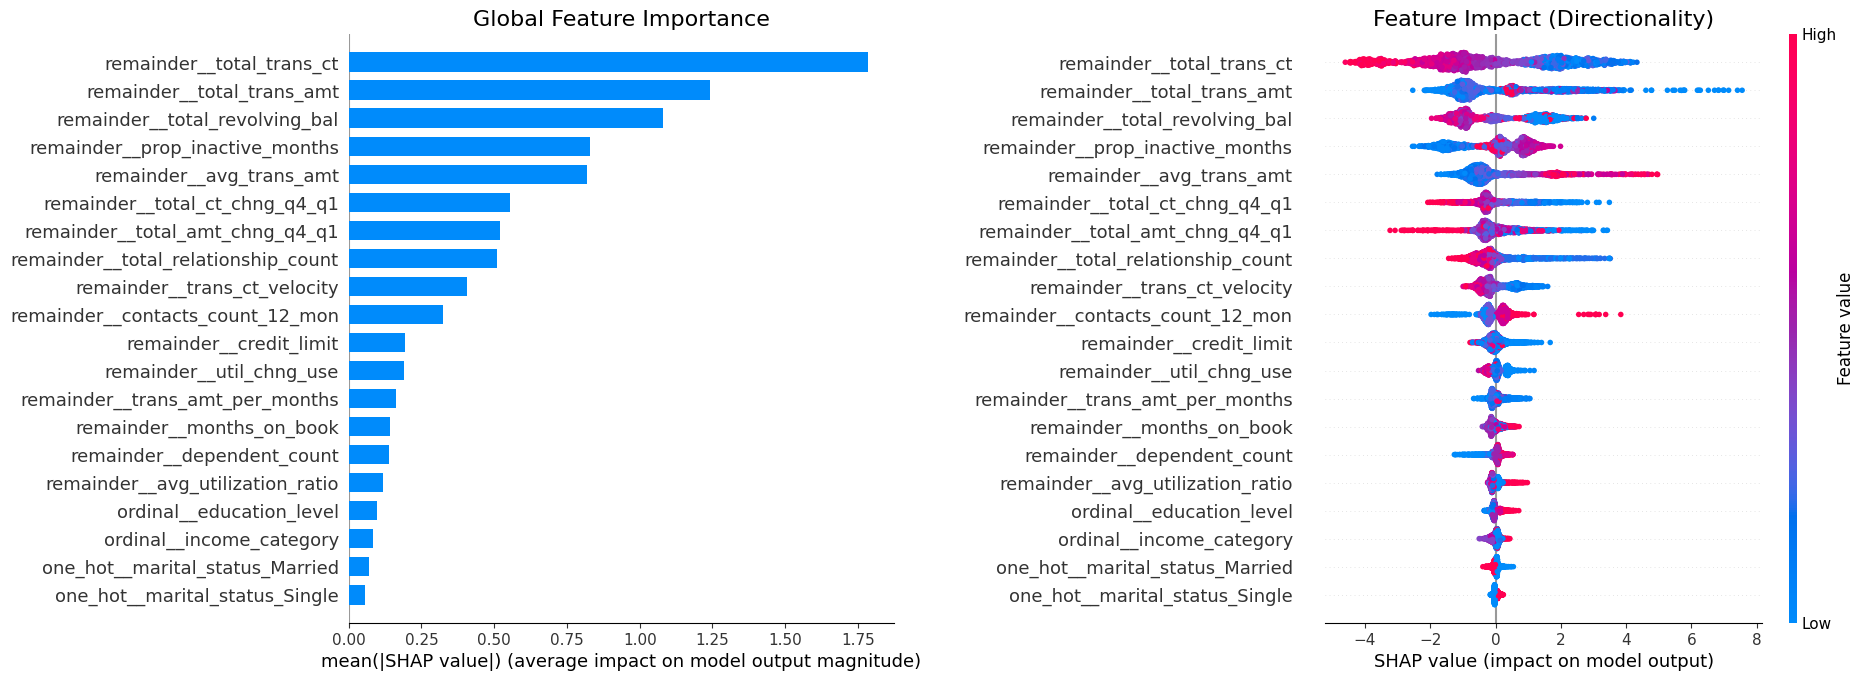

In [40]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

plt.sca(ax1) 
shap.summary_plot(shap_values, X_test_df, plot_type="bar", show=False, plot_size = None)
ax1.set_title("Global Feature Importance", fontsize=16)


plt.sca(ax2) 
shap.summary_plot(shap_values, X_test_df, show=False, plot_size = None)
ax2.set_title("Feature Impact (Directionality)", fontsize=16)

plt.tight_layout(pad=5.0)
plt.show()

These graphs clearly crown __total_trans_ct__ as the most critical churn driver in the model, but the remaining features are by no means to be glossed over. While no single variable matches the standalone predictive weight of transaction counts, the remaining behavioral features collectively carry just as much overall importance. Ultimately, the upcoming data leakage and model integrity tests will prove that this pipeline isn't just a "one-feature pony," but rather a robust, multi-dimensional model.

### Data Leakage and Model Integerity Test

In [41]:
from src.utils.data_leak_test import run_data_leak_tests
import pprint as pp

top_features = ['total_trans_amt', 'total_revolving_bal', 'total_trans_ct']
pp.pprint(run_data_leak_tests(final_pipeline, X_train, X_test, y_train, y_test, top_features))


{'drop_top_feature_test': {'base_roc_auc': 0.9919,
                           'dropped_roc_auc': 0.9627,
                           'impact': 0.0291,
                           'robustness': 'Robust'},
 'singular_tests': [{'auc_score': 0.8527,
                     'feature': 'total_trans_amt',
                     'status': 'No Leakage'},
                    {'auc_score': 0.7455,
                     'feature': 'total_revolving_bal',
                     'status': 'No Leakage'},
                    {'auc_score': 0.8259,
                     'feature': 'total_trans_ct',
                     'status': 'No Leakage'}]}


### Integrity Leakage Testing

To test the model's integrity and for any data leakage, two separate validation experiments were run through a single function:

> * __Top Feature Drop Test__: The first test dropped the feature with the greatest importance according to the SHAP plots (total_trans_ct) and then retrained the final pipeline on the remaining features in the dataset. This test resulted in a small __2.9% drop in AUC-ROC__. This confirms that, while the top feature carries significant weight, the model does not rely solely on it; it can still draw inferences from the other  remaining features to remain highly predictive and robust.

> * __Data Leakage Test__: The second test checked the top three features from the SHAP plots for any sign of data leakage. A threshold was set so that if any feature alone achieved an AUC-ROC above 0.90, it would be flagged as "__No leakage__," indicating that the feature was leaking information into the training set. Fortunately, no feature crossed the set threshold. While the features are strong indicators of churn, they do not leak results or support the entire model. This proves the pipeline's earlier high marks are legitimate.

### Financial Impact Analysis

In [ ]:
rev_trans = 0.03         # 3% margin on volume (industry avg)
rev_revolving = 0.05     # 5% margin on revolving balances
ret_offer = 100          # Standard retention offer cost
success_prob = 0.70      # Est. 70% success rate for targeted offers
cac_per_user = 167.00    # Replacement cost per user 
threshold = 0.50         # Risk threshold for targeting

# Get churn probabilities for the test set
churn_probs = final_pipeline.predict_proba(X_test)[:, 1]

# Small df of key features for financial impact analysis
impact_df = pd.DataFrame({
    'churn_prob': churn_probs,
    'total_trans_amt': X_test['total_trans_amt'].to_numpy(),
    'total_revolving_bal': X_test['total_revolving_bal'].to_numpy()
})

# Estimated yearly value per customer
impact_df['value_if_saved'] = (impact_df['total_trans_amt'] * rev_trans) + (impact_df['total_revolving_bal'] * rev_revolving)

# Expected retention value based on success probability and avoided replacement cost
impact_df['expected_retention_value'] = impact_df['churn_prob'] * success_prob * (impact_df['value_if_saved'] + cac_per_user)

# Net value after subtracting cost of the offer
impact_df['expected_net_value'] = impact_df['expected_retention_value'] - ret_offer

# Filter for customers above risk threshold
high_risk_df = impact_df[impact_df['churn_prob'] > threshold].copy()

# Target list: high-risk people where we actually expect to make a profit
profitable_targets = high_risk_df[high_risk_df['expected_net_value'] > 0].copy()

num_high_risk = len(high_risk_df)
num_targeted = len(profitable_targets)
expected_gross_value = profitable_targets['expected_retention_value'].sum()
expected_offer_cost = num_targeted * ret_offer
total_net_savings = profitable_targets['expected_net_value'].sum()
avg_net_value = profitable_targets['expected_net_value'].mean() if num_targeted else 0.0

print("Financial Impact Analysis")
print('------')
print(f"Total Customers Analyzed: {len(X_test)}")
print(f"High-risk customers (p > {threshold:.2f}): {num_high_risk}")
print(f"Profitable customers to target: {num_targeted}\n")
print('------')
print(f"Expected Gross Retained Value: ${expected_gross_value:,.2f}")
print(f"Cost of Retention Campaign: ${expected_offer_cost:,.2f}")
print(f"Total Estimated Net Savings: ${total_net_savings:,.2f}\n")
print('------')
print(f"ROI on Retention Spend: {(total_net_savings / expected_offer_cost) * 100:.1f}%")
print(f"Avg Net Value per Customer: ${avg_net_value:,.2f}")


Financial Impact Analysis
------
Total Customers Analyzed: 2026
High-risk customers (p > 0.50): 325
Profitable customers to target: 320

------
Expected Gross Retained Value: $63,219.65
Cost of Retention Campaign: $32,000.00
Total Estimated Net Savings: $31,219.65

------
ROI on Retention Spend: 97.6%
Avg Net Value per Customer: $97.56


#### Financial Impact & ROI Analysis

To demonstrate this pipeline’s real-world business flow, a financial impact analysis was conducted using standard banking baseline metrics. These metrics came from a quick internet search of standard banking practices. Guesstimates were used for the retention offer, the cost saved from retaining a customer, and a threshold for marking a customer as high risk. Individual transaction volumes (total_trans_amt) were mapped to a 3% volume margin. Revolving balances (total_revolving_bal) were mapped to a 5% revolving balance margin. Assuming a risk threshold of 0.50 (the predicted risk of churning is at least 50%), a $100 retention offer, and a 70% offer success rate, the model is used to determine whether saving the at-risk customers is worth the effort and money to consider the retention program a success.

> __Strategic Customer Targeting__: Of the 2,026 customers evaluated, the model flagged 325 as high risk (crossing the 0.50 churn threshold). Rather than extending offers to all 325 customers, the customer base was filtered by profitability, identifying 320 customers whose expected retention value exceeded the $100 cost of the retention offer. By filtering out the 5 unprofitable customers, the bank avoids wasting money on offers to accounts that would cost more to keep than the bank would get in return.

> __Net Savings__: Using a $100 retention offer to those 320 profitable customers would require an upfront investment of $32,000.00. In return, the model yielded an Expected Gross Retained Value of $63,219.65, thus doubling the initial investment. This would result in a Total Estimated Net Savings of $31,219.65, producing an average net recovery of $97.56 per the 320 customers.

> __Return on Investment (ROI)__: At a baseline 70% success rate, this strategy yields an ROI of 97.6%, representing a high yield for the investment campaign. Because the selection logic is optimized around account value, the campaign would remain low-risk, and even if the success rate were to drop to 50%, the revenue from this campaign would still break even, meaning there would be no expected loss.

Ultimately, this impact analysis shows that the model achieves a high F1 Score in isolation. It would also help protect the company’s revenue, optimize marketing for retention, and turn churn mitigation into a high-margin profit center.

